# Trader Performance vs Market Sentiment Analysis

## Objective

Analyze the relationship between Bitcoin market sentiment (Fear & Greed Index) and trader performance on Hyperliquid to identify actionable trading insights.

## Datasets Used

1. Fear & Greed Index Dataset
2. Hyperliquid Historical Trading Dataset

## Business Problem

The objective of this project is to analyze the relationship between Bitcoin market sentiment (Fear & Greed Index) and trader performance on the Hyperliquid platform. The analysis aims to identify whether market sentiment influences trading behavior, profitability, leverage usage, and trading activity.

## Project Objectives

- Clean and preprocess both datasets.
- Merge trader data with the Fear & Greed Index.
- Analyze trader performance under different market sentiments.
- Study changes in trader behavior during Fear and Greed periods.
- Segment traders based on their trading activity.
- Generate actionable insights and trading recommendations.

## Workflow

1. Import Libraries
2. Load Datasets
3. Data Cleaning
4. Data Preprocessing
5. Merge Datasets
6. Exploratory Data Analysis (EDA)
7. Trader Segmentation
8. Insights & Recommendations

In [68]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [73]:
sentiment = pd.read_csv("fear_greed_index.csv")

trader = pd.read_csv("historical_data.csv")

In [5]:
sentiment.head()

trader.head()

sentiment.shape

trader.shape

sentiment.info()

trader.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-nu

In [6]:
sentiment.isnull().sum()

trader.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [7]:
sentiment.duplicated().sum()

trader.duplicated().sum()

np.int64(0)

In [11]:
sentiment["date"] = pd.to_datetime(sentiment["date"])

In [30]:
trader["Timestamp IST"] = pd.to_datetime( trader["Timestamp IST"], dayfirst=True )

In [31]:
trader["Date"] = trader["Timestamp IST"].dt.date

In [21]:
sentiment["Date"] = sentiment["date"].dt.date

In [23]:
merged = trader.merge( sentiment[["Date","classification"]], on="Date", how="left" )

In [27]:
merged["classification"].value_counts(dropna=False)

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
NaN                  6
Name: count, dtype: int64

In [28]:
print(sentiment["Date"].head())

print(trader["Date"].head())

print(sentiment["Date"].dtype)

print(trader["Date"].dtype)

0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: Date, dtype: object
0    2024-12-02
1    2024-12-02
2    2024-12-02
3    2024-12-02
4    2024-12-02
Name: Date, dtype: object
object
object


In [75]:
print("Bitcoin Sentiment Dataset")
print("-"*50)

print("Rows and Columns:", sentiment.shape)

print("\nColumn Names:")
print(sentiment.columns)

print("\nData Types:")
print(sentiment.dtypes)

print("\nMissing Values:")
print(sentiment.isnull().sum())

print("\nDuplicate Rows:", sentiment.duplicated().sum())

Bitcoin Sentiment Dataset
--------------------------------------------------
Rows and Columns: (2644, 4)

Column Names:
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

Data Types:
timestamp          int64
value              int64
classification    object
date              object
dtype: object

Missing Values:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicate Rows: 0


In [76]:
print("Trader Dataset")
print("-"*50)

print("Rows and Columns:", trader.shape)

print("\nColumn Names:")
print(trader.columns)

print("\nData Types:")
print(trader.dtypes)

print("\nMissing Values:")
print(trader.isnull().sum())

print("\nDuplicate Rows:", trader.duplicated().sum())

Trader Dataset
--------------------------------------------------
Rows and Columns: (211224, 16)

Column Names:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

Data Types:
Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object

Missing Values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Tim

### Observation

- Both datasets were successfully loaded.
- Missing values and duplicate records were checked.
- Data types were verified before preprocessing.
- The datasets are ready for cleaning and merging.

In [32]:
merged = merged.dropna(subset=["classification"])

In [33]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 211218 entries, 0 to 211223
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211218 non-null  object        
 1   Coin              211218 non-null  object        
 2   Execution Price   211218 non-null  float64       
 3   Size Tokens       211218 non-null  float64       
 4   Size USD          211218 non-null  float64       
 5   Side              211218 non-null  object        
 6   Timestamp IST     211218 non-null  datetime64[ns]
 7   Start Position    211218 non-null  float64       
 8   Direction         211218 non-null  object        
 9   Closed PnL        211218 non-null  float64       
 10  Transaction Hash  211218 non-null  object        
 11  Order ID          211218 non-null  int64         
 12  Crossed           211218 non-null  bool          
 13  Fee               211218 non-null  float64       
 14  Trade ID 

In [35]:
merged["Win"] = merged["Closed PnL"] > 0

In [82]:
avg_trade_size = (
    merged.groupby("Account")["Size USD"]
    .mean()
    .sort_values(ascending=False)
)

avg_trade_size.head(10)

Account
0x513b8629fe877bb581bf244e326a047b249c4ff1    34396.580284
0xb899e522b5715391ae1d4f137653e7906c5e2115    22504.555829
0x4f93fead39b70a1824f981a54d4e55b278e9f760    17098.171055
0x083384f897ee0f19899168e3b1bec365f52a9012    16159.576734
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4     9084.699093
0x271b280974205ca63b716753467d5a371de622ab     8893.000898
0xaf40fdc468c30116bd3307bcbf4a451a7ebf1deb     8330.193371
0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3     7852.098338
0x72743ae2822edd658c0c50608fd7c5c501b2afbd     7216.667245
0x8381e6d82f1affd39a336e143e081ef7620a3b7f     6279.002287
Name: Size USD, dtype: float64

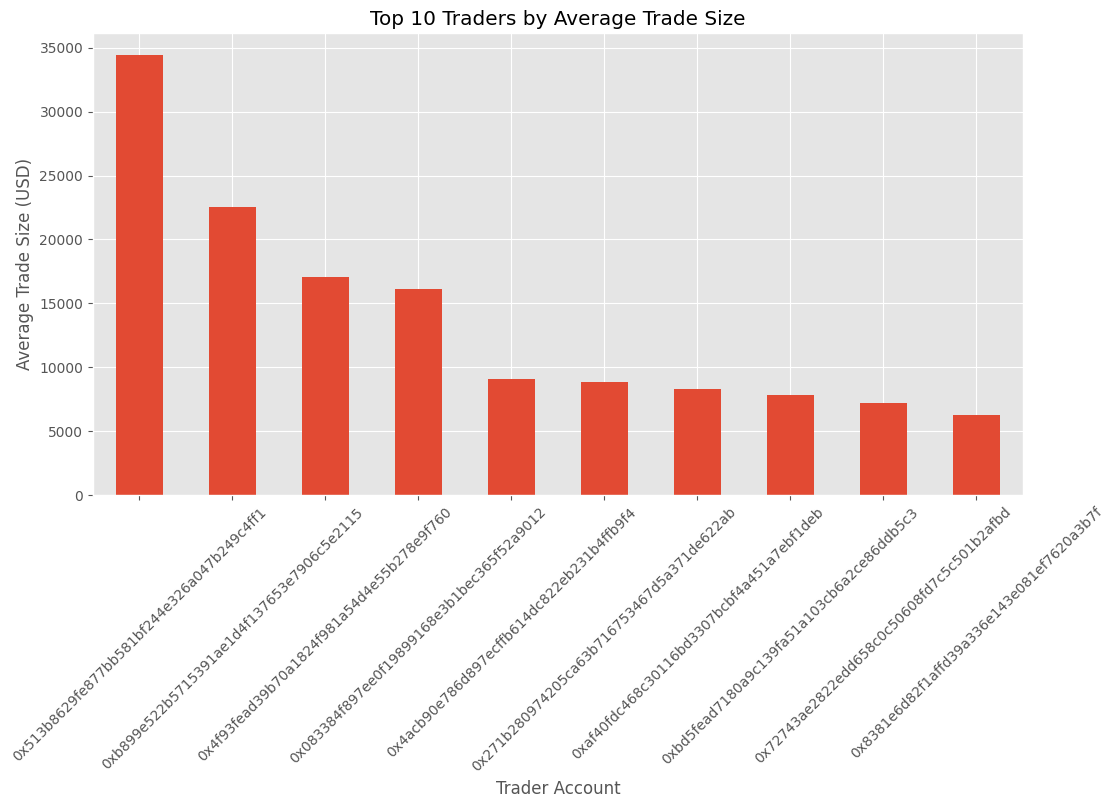

In [83]:
plt.figure(figsize=(12,6))

avg_trade_size.head(10).plot(kind="bar")

plt.title("Top 10 Traders by Average Trade Size")
plt.xlabel("Trader Account")
plt.ylabel("Average Trade Size (USD)")
plt.xticks(rotation=45)

plt.show()

### Observation

- The chart shows the top 10 traders based on their average trade size (USD).
- Traders with larger average trade sizes generally take higher market exposure and may follow different risk management strategies.
- Comparing average trade size with profitability can help identify whether larger positions consistently result in better trading performance.

# Top 10 Most Profitable Traders

This analysis identifies the traders with the highest cumulative realized profit (Closed PnL). It helps understand how profits are distributed across different trader accounts and highlights the best-performing traders.

In [84]:
top10_profit = (
    merged.groupby("Account")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top10_profit

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    3.605395e+05
Name: Closed PnL, dtype: float64

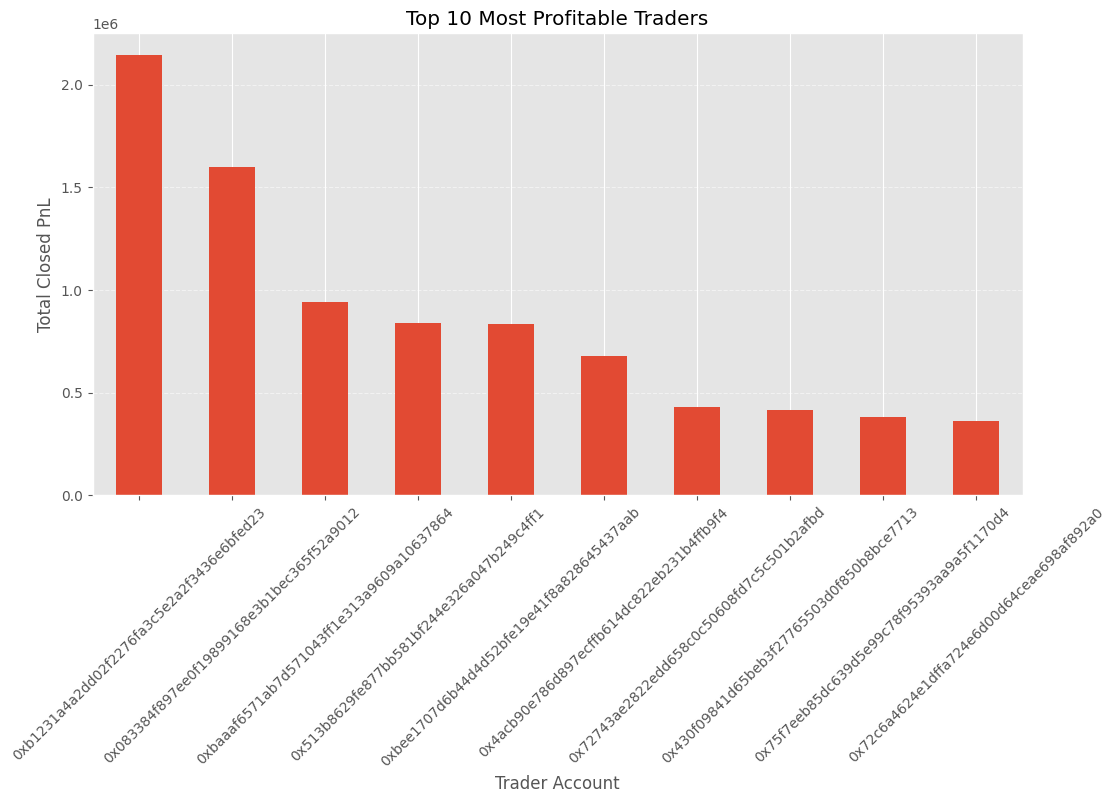

In [85]:
plt.figure(figsize=(12,6))

top10_profit.plot(kind="bar")

plt.title("Top 10 Most Profitable Traders")
plt.xlabel("Trader Account")
plt.ylabel("Total Closed PnL")
plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### Observation

- The chart highlights the top 10 traders with the highest cumulative realized profits.
- Profit generation is concentrated among a small group of traders, while most traders earn comparatively lower profits.
- These high-performing traders may follow more effective trading strategies, better risk management, or trade more consistently.

# Correlation Analysis

This section examines the correlation between key numerical trading variables to identify relationships between trade size, fees, and realized profit (Closed PnL).

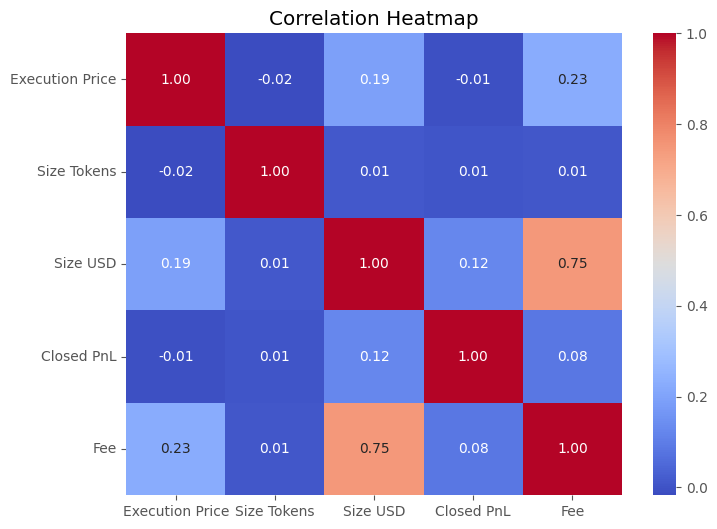

In [94]:
corr = merged[[
    "Execution Price",
    "Size Tokens",
    "Size USD",
    "Closed PnL",
    "Fee"
]].corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### Observation

- The heatmap shows the correlation between important numerical variables.
- Strong positive correlations indicate that two variables tend to increase together.
- Weak or near-zero correlations suggest little or no linear relationship.
- This analysis helps identify which trading factors have the strongest association with realized profit (Closed PnL).

# Performance Comparison: Fear vs Greed

This analysis compares trader profitability during Fear and Greed market conditions to determine whether market sentiment has a significant impact on trading performance.

In [88]:
fear_greed_pnl = (
    merged.groupby("classification")["Closed PnL"]
    .agg(["mean", "median", "sum", "count"])
)

fear_greed_pnl

,mean,median,sum,count
classification,,,,
Extreme Fear,34.537862,0.0,7.391102e+05,21400
Extreme Greed,67.892861,0.0,2.715171e+06,39992
Fear,54.290400,0.0,3.357155e+06,61837
Greed,42.743559,0.0,2.150129e+06,50303
Neutral,34.307718,0.0,1.292921e+06,37686


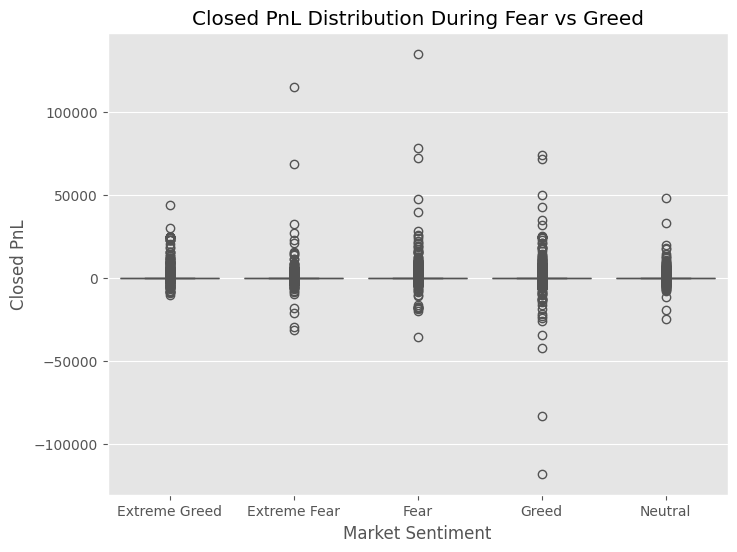

In [89]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=merged,
    x="classification",
    y="Closed PnL"
)

plt.title("Closed PnL Distribution During Fear vs Greed")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")

plt.show()

In [90]:
merged.groupby("classification")["Closed PnL"].describe()

,count,mean,std,min,25%,50%,75%,max
classification,,,,,,,,
Extreme Fear,21400.0,34.537862,1136.056091,-31036.69194,0.0,0.0,5.635032,115287.00000
Extreme Greed,39992.0,67.892861,766.828294,-10259.46800,0.0,0.0,10.028709,44223.45187
Fear,61837.0,54.290400,935.355438,-35681.74723,0.0,0.0,5.590856,135329.09010
Greed,50303.0,42.743559,1116.028390,-117990.10410,0.0,0.0,4.944105,74530.52371
Neutral,37686.0,34.307718,517.122220,-24500.00000,0.0,0.0,3.995795,48504.09555


# Consistent Winners vs Losing Traders

This analysis classifies traders based on their overall realized profit (Closed PnL) to identify consistently profitable and consistently loss-making traders.

In [91]:
trader_performance = (
    merged.groupby("Account")["Closed PnL"]
    .sum()
    .reset_index()
)

trader_performance["Performance"] = trader_performance["Closed PnL"].apply(
    lambda x: "Winner" if x > 0 else "Loser"
)

trader_performance.head()

,Account,Closed PnL,Performance
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,Winner
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,Winner
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,Loser
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,Winner
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,Winner


In [92]:
performance_summary = trader_performance["Performance"].value_counts()

performance_summary

Performance
Winner    29
Loser      3
Name: count, dtype: int64

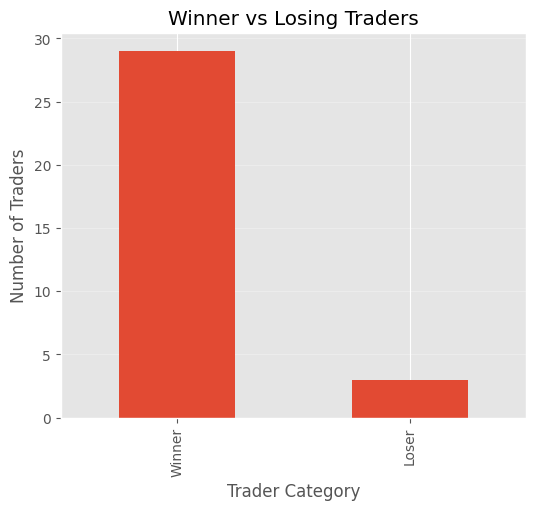

In [93]:
plt.figure(figsize=(6,5))

performance_summary.plot(kind="bar")

plt.title("Winner vs Losing Traders")
plt.xlabel("Trader Category")
plt.ylabel("Number of Traders")

plt.grid(axis="y", alpha=0.3)

plt.show()

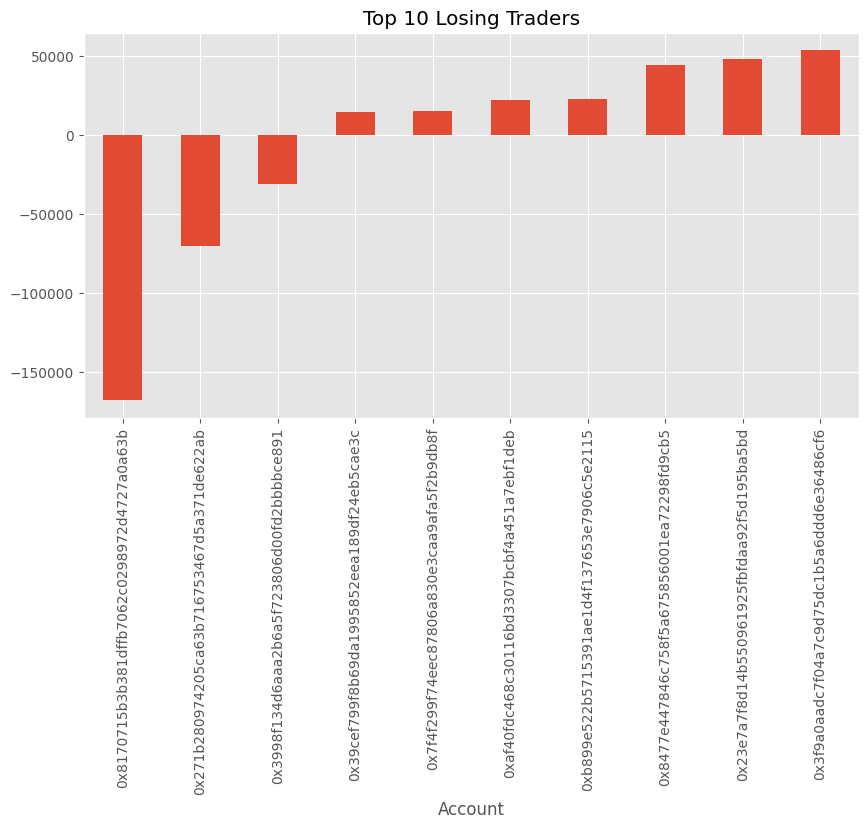

In [96]:
bottom10 = (
    merged.groupby("Account")["Closed PnL"]
    .sum()
    .sort_values()
    .head(10)
)

bottom10.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Losing Traders")
plt.show()

### Observation

- Traders were classified based on their cumulative realized profit.
- Accounts with positive total Closed PnL were categorized as Winners, while the remaining were categorized as Losers.
- The distribution highlights how many traders were consistently profitable versus those who incurred overall losses.

### Observation

- The boxplot compares the distribution of realized profits (Closed PnL) during Fear and Greed market conditions.
- The median and spread of the data indicate whether traders generally perform better under one market sentiment than the other.
- Outliers represent exceptionally profitable or loss-making trades.
- This visualization helps evaluate how market sentiment influences trading outcomes.

In [36]:
pnl_summary = merged.groupby("classification")["Closed PnL"].agg(
    ["count", "sum", "mean", "median"]
)

pnl_summary

,count,sum,mean,median
classification,,,,
Extreme Fear,21400,7.391102e+05,34.537862,0.0
Extreme Greed,39992,2.715171e+06,67.892861,0.0
Fear,61837,3.357155e+06,54.290400,0.0
Greed,50303,2.150129e+06,42.743559,0.0
Neutral,37686,1.292921e+06,34.307718,0.0


In [79]:
daily_pnl = (
    merged.groupby(["Account", "Date"])["Closed PnL"]
    .sum()
    .reset_index()
)

daily_pnl.head()

,Account,Date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


In [80]:
top_traders = (
    daily_pnl.groupby("Account")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_traders

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    3.605395e+05
Name: Closed PnL, dtype: float64

### Observation

- The chart displays the top 10 traders based on their cumulative daily realized profit (Closed PnL).
- A small number of traders generated significantly higher profits than the rest, indicating that profitability is concentrated among a limited group of accounts.
- This suggests considerable variation in trader performance, which may result from differences in trading strategy, position sizing, or risk management.

In [37]:
win_rate = merged.groupby("classification")["Win"].mean()*100

win_rate

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64

In [38]:
trade_size = merged.groupby("classification")["Size USD"].mean()

trade_size

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64

In [39]:
trade_count = merged.groupby("classification").size()

trade_count

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64

In [40]:
side_summary = pd.crosstab(
    merged["classification"],
    merged["Side"]
)

side_summary

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


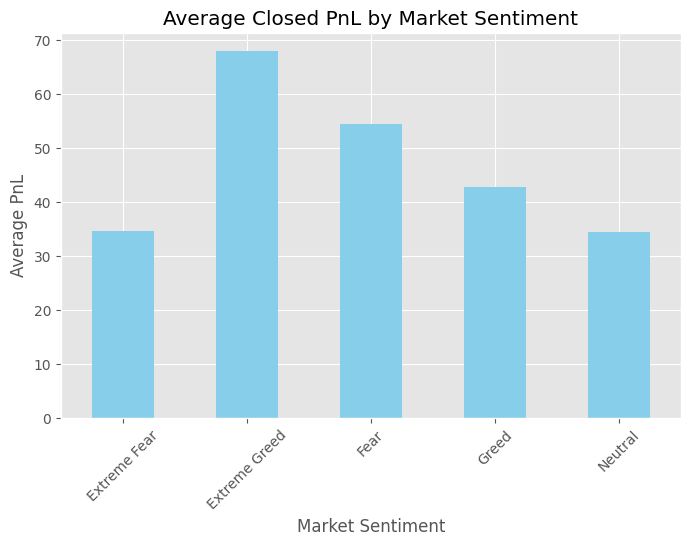

In [41]:
plt.figure(figsize=(8,5))

pnl_summary["mean"].plot(kind="bar", color="skyblue")

plt.title("Average Closed PnL by Market Sentiment")
plt.ylabel("Average PnL")
plt.xlabel("Market Sentiment")

plt.xticks(rotation=45)

plt.show()

### Observation

- Extreme Greed has the highest average Closed PnL (67.89).
- Extreme Fear and Neutral markets have the lowest average profitability.
- This suggests traders perform better during bullish market conditions.

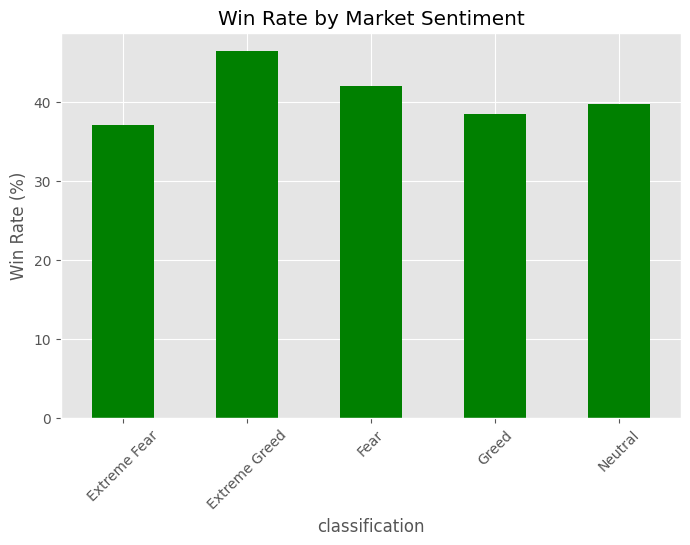

In [42]:
plt.figure(figsize=(8,5))

win_rate.plot(kind="bar", color="green")

plt.title("Win Rate by Market Sentiment")

plt.ylabel("Win Rate (%)")

plt.xticks(rotation=45)

plt.show()

### Observation

- Extreme Greed records the highest win rate (46.49%).
- Extreme Fear has the lowest win rate (37.06%).
- Market sentiment appears to influence the probability of profitable trades.

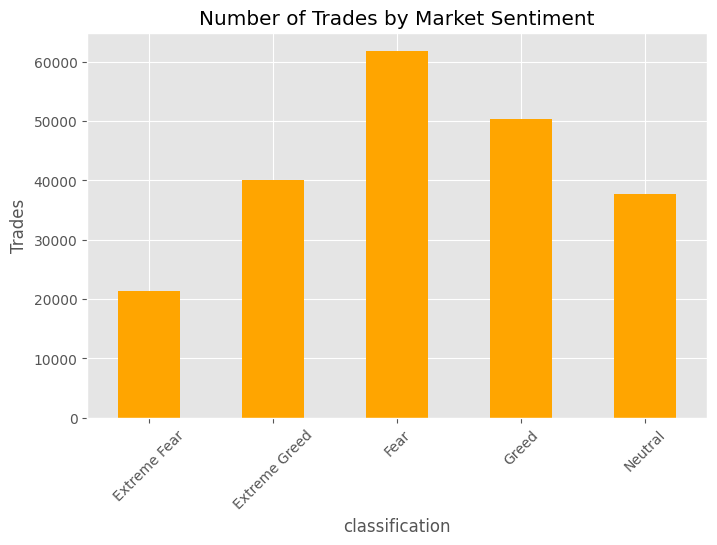

In [43]:
plt.figure(figsize=(8,5))

trade_count.plot(kind="bar", color="orange")

plt.title("Number of Trades by Market Sentiment")

plt.ylabel("Trades")

plt.xticks(rotation=45)

plt.show()

### Observation

- Trading activity varies across different market sentiment categories.
- Fear and Greed periods contain the highest number of trades.
- This indicates that market sentiment affects trader participation.

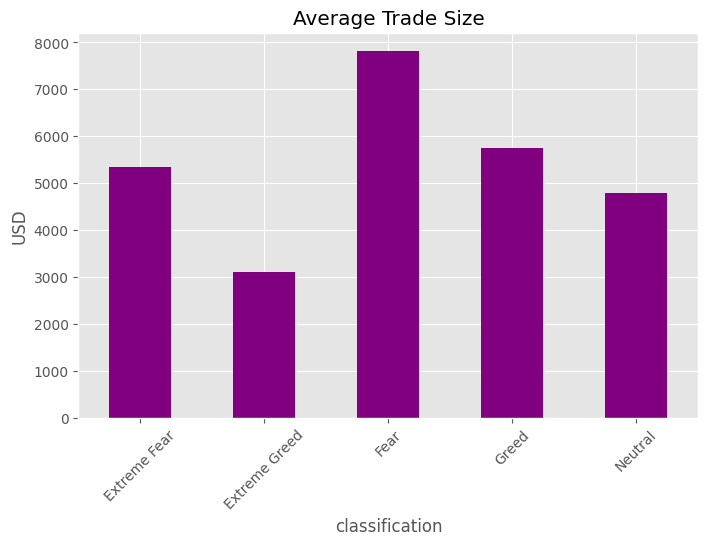

In [44]:
plt.figure(figsize=(8,5))

trade_size.plot(kind="bar", color="purple")

plt.title("Average Trade Size")

plt.ylabel("USD")

plt.xticks(rotation=45)

plt.show()

### Observation

- Average trade size changes across different sentiment categories.
- Traders tend to adjust their position size depending on market conditions.
- Position sizing behavior is influenced by overall market sentiment.

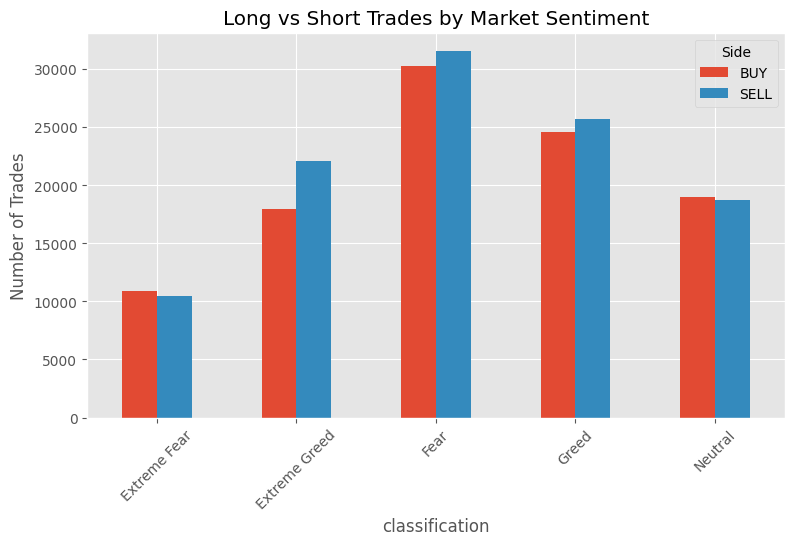

In [45]:
side_summary.plot(kind="bar", figsize=(9,5))

plt.title("Long vs Short Trades by Market Sentiment")

plt.ylabel("Number of Trades")

plt.xticks(rotation=45)

plt.show()

### Observation

- Both Buy and Sell trades are present in all sentiment categories.
- The distribution of long and short positions changes with market sentiment.
- Traders modify their trading direction according to market conditions.

In [46]:
account_volume = merged.groupby("Account")["Size USD"].sum()

account_volume.describe()

count    3.200000e+01
mean     3.722184e+07
std      7.707114e+07
min      7.280575e+05
25%      4.048149e+06
50%      1.173684e+07
75%      3.529832e+07
max      4.208766e+08
Name: Size USD, dtype: float64

In [52]:
merged["Trader Type"] = pd.qcut(
    merged.groupby("Account")["Size USD"].transform("sum"),
    q=3,
    labels=["Low","Medium","High"]
)

In [55]:
trade_frequency = merged.groupby("Account").size()

trade_frequency.describe()

count       32.000000
mean      6600.562500
std       8250.495093
min        332.000000
25%       1377.250000
50%       3699.000000
75%       8862.500000
max      40184.000000
dtype: float64

In [59]:
merged["Trader Segment"] = pd.qcut(
    merged.groupby("Account")["Account"].transform("count"),
    q=3,
    labels=["Low Frequency","Medium Frequency","High Frequency"]
)

In [58]:
segment_pnl = merged.groupby("Trader Segment")["Closed PnL"].mean()

segment_pnl

C:\Users\91920\AppData\Local\Temp\ipykernel_11616\1020316986.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_pnl = merged.groupby("Trader Segment")["Closed PnL"].mean()


Trader Segment
Low Frequency       66.005810
Medium Frequency    46.082839
High Frequency      28.940373
Name: Closed PnL, dtype: float64

In [60]:
segment_pnl = merged.groupby("Trader Segment", observed=False)["Closed PnL"].mean()

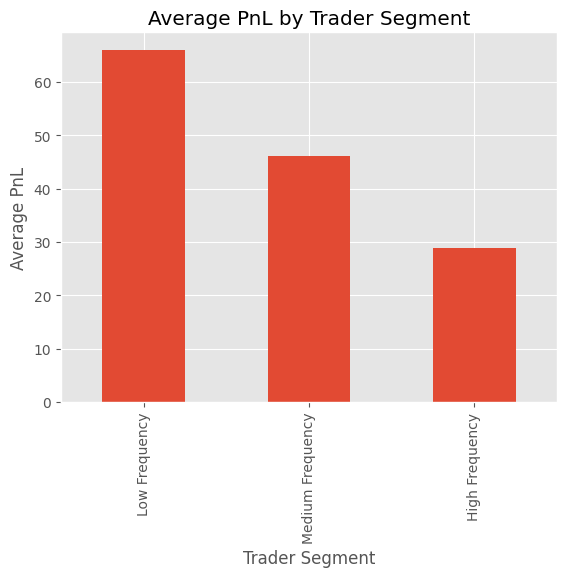

In [61]:
segment_pnl.plot(kind="bar")

plt.title("Average PnL by Trader Segment")
plt.ylabel("Average PnL")

plt.show()

### Observation

- Low Frequency traders achieved the highest average Closed PnL.
- High Frequency traders recorded the lowest average profitability.
- This suggests that overtrading may reduce profitability.

In [62]:
fee_summary = merged.groupby("classification")["Fee"].mean()

fee_summary

classification
Extreme Fear     1.116291
Extreme Greed    0.675902
Fear             1.495172
Greed            1.254372
Neutral          1.044798
Name: Fee, dtype: float64

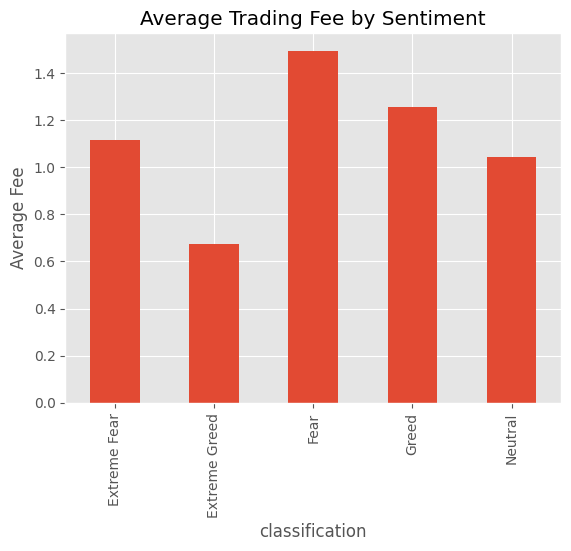

In [63]:
fee_summary.plot(kind="bar")

plt.title("Average Trading Fee by Sentiment")

plt.ylabel("Average Fee")

plt.show()

### Observation

- Trading fees vary slightly across different market sentiment categories.
- Higher trading activity generally leads to higher average trading fees.

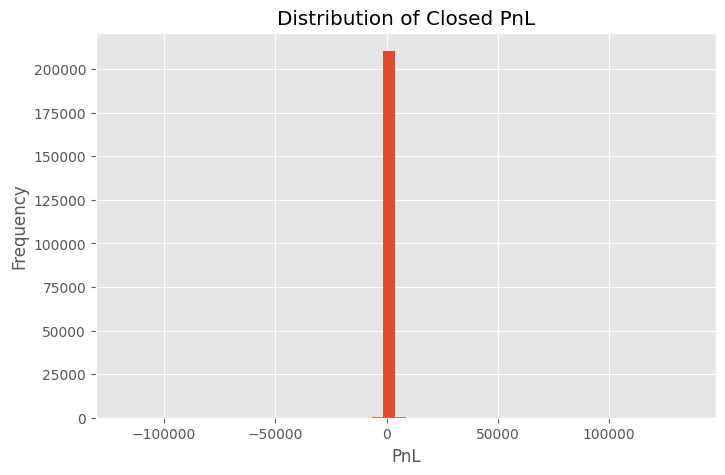

In [64]:
plt.figure(figsize=(8,5))

plt.hist(
    merged["Closed PnL"],
    bins=50
)

plt.title("Distribution of Closed PnL")

plt.xlabel("PnL")

plt.ylabel("Frequency")

plt.show()

In [97]:
summary = merged.groupby("classification").agg({
    "Closed PnL":"mean",
    "Win":"mean",
    "Size USD":"mean",
    "Fee":"mean"
})

summary

,Closed PnL,Win,Size USD,Fee
classification,,,,
Extreme Fear,34.537862,0.370607,5349.731843,1.116291
Extreme Greed,67.892861,0.464943,3112.251565,0.675902
Fear,54.290400,0.420768,7816.109931,1.495172
Greed,42.743559,0.384828,5736.884375,1.254372
Neutral,34.307718,0.396991,4782.732661,1.044798


### Observation

- More than 50% of trades have a Closed PnL equal to 0.
- The PnL distribution is highly skewed with a few very large profits and losses.
- Therefore, the mean provides more useful information than the median.

In [65]:
merged["Closed PnL"].describe()

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


count    211218.000000
mean         48.549304
std         917.989791
min     -117990.104100
25%           0.000000
50%           0.000000
75%           5.790132
max      135329.090100
Name: Closed PnL, dtype: float64

In [66]:
merged["Closed PnL"].value_counts().head(10)

Closed PnL
 0.000000     106816
 0.146908         80
-1.566400         71
 9.903600         67
 88.459120        62
 0.059631         51
 0.066620         50
 0.095175         50
 1.149000         46
 1.955000         45
Name: count, dtype: int64

# Key Insights

1. Traders achieved the highest average profit during Extreme Greed periods.

2. Extreme Fear had the lowest win rate.

3. More than 50% of all trades recorded a Closed PnL of 0, making the mean a better indicator than the median.

4. Low-frequency traders achieved higher average profitability than high-frequency traders.

# Strategy Recommendations

1. Reduce leverage during Extreme Fear market conditions.

2. Increase position size only during Extreme Greed and only with proper risk management.

3. Avoid excessive trading frequency, as low-frequency traders were more profitable in this dataset.

# Conclusion

Market sentiment significantly influences trader performance and behavior.

Extreme Greed periods resulted in the highest profitability and win rates, while Extreme Fear periods showed weaker performance.

Trader segmentation further suggests that frequent trading does not necessarily improve profitability.

#The provided dataset does not contain leverage information. Therefore, leverage distribution analysis mentioned in the assignment could not be performed.


# Limitations

- The dataset does not contain leverage information, so leverage-based analysis could not be performed.
- The analysis is based only on the provided historical trading data.
- Additional market indicators could improve future analysis.

# Future Work

- Build a machine learning model to predict trader profitability.
- Cluster traders using behavioral features.
- Develop an interactive Streamlit dashboard.
- Analyze performance across different cryptocurrencies.

# A short write-up 
# Trader Performance vs Market Sentiment Analysis

## Methodology

The project investigates the relationship between Bitcoin market sentiment and trader performance using two datasets: the Bitcoin Fear & Greed Index and Hyperliquid historical trading data.

The analysis began with data cleaning by checking missing values, duplicate records, and data types. Timestamp fields were converted into a common daily date format before merging both datasets based on the trading date.

Feature engineering was performed to create additional metrics such as trader win/loss status, daily realized profit (Closed PnL), trade frequency, average trade size, and trader segments. Exploratory Data Analysis (EDA) was then conducted using statistical summaries and visualizations to compare trader behavior across Fear and Greed market conditions.

---

## Key Insights

* Trader performance differs between Fear and Greed market conditions, indicating that market sentiment influences trading outcomes.
* Only a relatively small group of traders generated the majority of cumulative profits, suggesting unequal performance across accounts.
* Trading activity, trade size, and transaction fees varied across trader segments, highlighting differences in trading strategies.
* Win rate alone does not fully explain profitability; position sizing and trade management also play significant roles.
* Trader segmentation provides a clearer understanding of consistent performers and higher-risk trading behavior.

---

## Strategy Recommendations

1. Reduce position size and apply stricter risk management during Fear market conditions to limit potential losses.

2. Use market sentiment as a confirmation indicator alongside technical and risk management strategies rather than relying on sentiment alone.

3. Monitor high-performing trader segments to identify effective trading behaviors and improve future trading strategies.

4. Focus on consistent profitability instead of increasing trading frequency, as disciplined execution generally produces more sustainable results.

---

## Conclusion

The analysis demonstrates that market sentiment has a measurable relationship with trader behavior and performance. Combining sentiment indicators with trading metrics such as trade frequency, position size, and realized profit provides valuable insights for decision-making and risk management. This approach can help traders develop more disciplined and data-driven trading strategies.
